In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset
df = pd.read_csv("/Users/nikitalondhe/Downloads/Assignment_4/goog.csv")
df.head(5)


,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [223]:
df.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

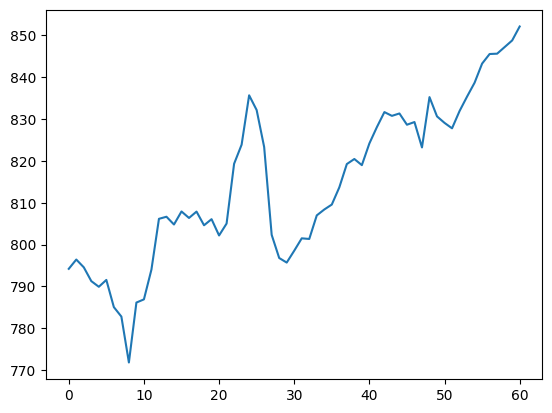

In [224]:
plt.plot(df['Close'])

In [225]:
data=df['Close'].values

In [226]:
data

array([794.200012, 796.419983, 794.559998, 791.26001 , 789.909973,
       791.549988, 785.049988, 782.789978, 771.820007, 786.140015,
       786.900024, 794.02002 , 806.150024, 806.650024, 804.789978,
       807.909973, 806.359985, 807.880005, 804.609985, 806.070007,
       802.174988, 805.02002 , 819.309998, 823.869995, 835.669983,
       832.150024, 823.309998, 802.320007, 796.789978, 795.695007,
       798.530029, 801.48999 , 801.340027, 806.969971, 808.380005,
       809.559998, 813.669983, 819.23999 , 820.450012, 818.97998 ,
       824.159973, 828.070007, 831.659973, 830.76001 , 831.330017,
       828.640015, 829.280029, 823.210022, 835.23999 , 830.630005,
       829.080017, 827.780029, 831.909973, 835.369995, 838.679993,
       843.25    , 845.539978, 845.619995, 847.200012, 848.780029,
       852.119995])

In [227]:
data.shape

(61,)

In [228]:
data=data.reshape(-1,1)

In [229]:
data.shape

(61, 1)

In [230]:
scaler=MinMaxScaler()
data=scaler.fit_transform(data)

In [231]:
data

array([[0.27870496],
       [0.30635093],
       [0.28318798],
       [0.24209223],
       [0.22527981],
       [0.24570341],
       [0.16475695],
       [0.13661236],
       [0.        ],
       [0.17833138],
       [0.18779601],
       [0.27646347],
       [0.42752207],
       [0.43374872],
       [0.41058501],
       [0.44943925],
       [0.43013678],
       [0.44906604],
       [0.4083435 ],
       [0.42652559],
       [0.37801975],
       [0.41344979],
       [0.5914072 ],
       [0.64819422],
       [0.79514303],
       [0.75130792],
       [0.64122041],
       [0.37982571],
       [0.31095859],
       [0.29732258],
       [0.33262797],
       [0.36948926],
       [0.36762172],
       [0.43773312],
       [0.4552927 ],
       [0.4699875 ],
       [0.52117039],
       [0.59053537],
       [0.60560414],
       [0.58729739],
       [0.6518054 ],
       [0.70049824],
       [0.74520517],
       [0.73399766],
       [0.74109613],
       [0.70759672],
       [0.71556701],
       [0.639

In [232]:
#split training and testing data
train_size=int(len(data)*0.8)
train_size

48

In [233]:
train_data=data[:train_size]
test_data=data[train_size:]
test_data

array([[0.7897882 ],
       [0.73237866],
       [0.7130762 ],
       [0.69688705],
       [0.74831849],
       [0.79140719],
       [0.8326276 ],
       [0.88953927],
       [0.91805706],
       [0.91905354],
       [0.93872997],
       [0.95840639],
       [1.        ]])

In [234]:
def create_dataset(dataset,time_stamp):
    x=[]
    y=[]
    for i in range(len(dataset)-time_stamp):
        x.append(dataset[i:i+time_stamp,0])
        y.append(dataset[i+time_stamp,0])
    return np.array(x),np.array(y)

In [235]:
x_train,y_train=create_dataset(train_data,4)
x_test,y_test=create_dataset(test_data,4)

In [236]:
x_train.shape
x_test.shape

(9, 4)

In [237]:
x_train=x_train.reshape(44,4,1)
x_test=x_test.reshape(9,4,1)

In [238]:
model=Sequential()
model.add(LSTM(64,input_shape=(4,1)))
model.add(Dense(1))

/Users/nikitalondhe/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [239]:
model.compile(optimizer='adam',loss='mse')

In [240]:
model.fit(x_train,y_train,epochs=30)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2500  
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2090
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1863
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1658
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1366
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1093
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0934
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0740
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0549
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0432
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0310
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0226
Epoch 13/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0199
Epoch 14/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0183
Epoch 15/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0201
Epoch 16/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

In [241]:
model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0376


0.03760024160146713

In [242]:
y_pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [243]:
y_pred

array([[0.64697623],
       [0.63578624],
       [0.6426537 ],
       [0.6612164 ],
       [0.6926508 ],
       [0.7215412 ],
       [0.7450925 ],
       [0.7638878 ],
       [0.77518773]], dtype=float32)

In [244]:
y_pred=scaler.inverse_transform(y_pred)

In [245]:
y_pred

array([[823.7722 ],
       [822.8736 ],
       [823.42505],
       [824.9157 ],
       [827.4399 ],
       [829.75977],
       [831.65094],
       [833.16016],
       [834.06757]], dtype=float32)

In [246]:
y_test=scaler.inverse_transform(y_test.reshape(-1,1))
y_test

array([[831.909973],
       [835.369995],
       [838.679993],
       [843.25    ],
       [845.539978],
       [845.619995],
       [847.200012],
       [848.780029],
       [852.119995]])

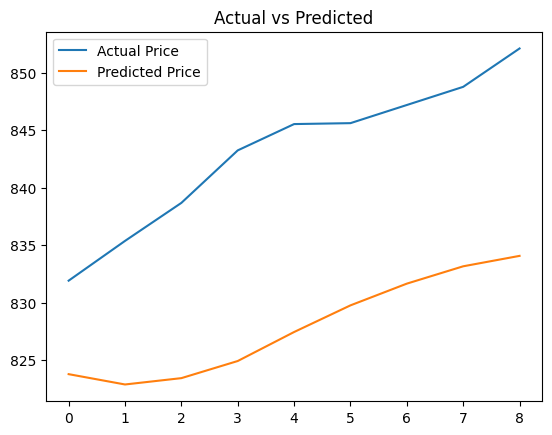

In [247]:
plt.plot(y_test,label='Actual Price')
plt.plot(y_pred,label='Predicted Price')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()